In [1]:
from keras.datasets import imdb
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000)

In [2]:
train_data[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [3]:
train_labels[0]

1

In [4]:
max([max(sequence) for sequence in train_data])

9999

In [5]:
word_index = imdb.get_word_index()
reversed_word_index = dict(
    [(value, key) for (key,value) in word_index.items()])
decoded_view = " ".join(
    [reversed_word_index.get(i - 3, "?") for i in train_data[0]]
)

In [6]:
import numpy as np
def vertorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1.
    return results
x_train = vertorize_sequences(train_data)
x_test = vertorize_sequences(test_data)

In [7]:
x_train[0]

array([0., 1., 1., ..., 0., 0., 0.])

In [8]:
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

In [9]:
import keras
from keras import layers

model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

In [10]:
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [11]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [12]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20


30/30 [==============================] - 4s 75ms/step - loss: 0.5614 - accuracy: 0.7733 - val_loss: 0.4419 - val_accuracy: 0.8597
Epoch 2/20
30/30 [==============================] - 1s 31ms/step - loss: 0.3650 - accuracy: 0.8864 - val_loss: 0.3609 - val_accuracy: 0.8529
Epoch 3/20
30/30 [==============================] - 1s 31ms/step - loss: 0.2720 - accuracy: 0.9102 - val_loss: 0.3070 - val_accuracy: 0.8807
Epoch 4/20
30/30 [==============================] - 1s 32ms/step - loss: 0.2185 - accuracy: 0.9266 - val_loss: 0.2960 - val_accuracy: 0.8823
Epoch 5/20
30/30 [==============================] - 1s 29ms/step - loss: 0.1840 - accuracy: 0.9387 - val_loss: 0.3088 - val_accuracy: 0.8762
Epoch 6/20
30/30 [==============================] - 1s 31ms/step - loss: 0.1556 - accuracy: 0.9487 - val_loss: 0.2797 - val_accuracy: 0.8871
Epoch 7/20
30/30 [==============================] - 1s 27ms/step - loss: 0.1363 - accuracy: 0.9551 - val_loss: 0.2939 - val_accuracy: 0.8823
Epoch 8/20


In [13]:
history_dict = history.history
history_dict.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

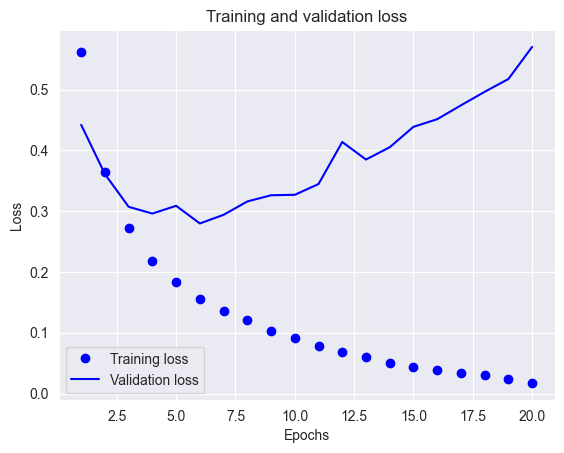

In [14]:
import matplotlib.pyplot as plt
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

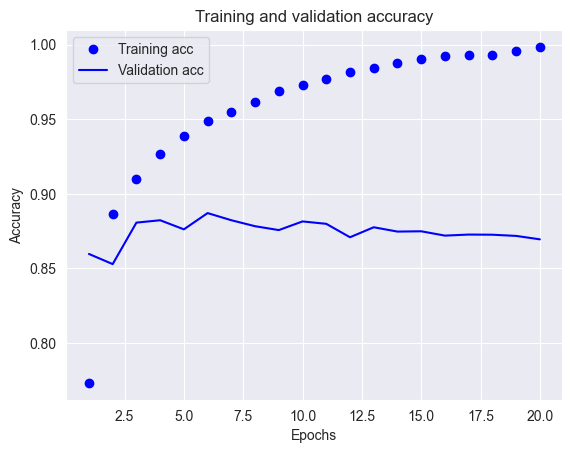

In [15]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [18]:
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

model.fit(x_train, y_train, epochs=4, batch_size=512)

results = model.evaluate(x_test, y_test)

Epoch 1/4
49/49 [==============================] - 1s 11ms/step - loss: 0.4936 - accuracy: 0.8058
Epoch 2/4
49/49 [==============================] - 0s 10ms/step - loss: 0.2881 - accuracy: 0.8996
Epoch 3/4
49/49 [==============================] - 1s 11ms/step - loss: 0.2243 - accuracy: 0.9187
Epoch 4/4
782/782 [==============================] - 2s 3ms/step - loss: 0.2820 - accuracy: 0.8863


In [19]:
results

[0.2820320427417755, 0.8862800002098083]

In [20]:
model.predict(x_test)

782/782 [==============================] - 3s 3ms/step


array([[0.17336462],
       [0.99932206],
       [0.85669726],
       ...,
       [0.0932081 ],
       [0.08190657],
       [0.6265027 ]], dtype=float32)

In [1]:
import keras
from keras.datasets import imdb
from keras import layers
(train_data, train_labels), _= imdb.load_data(num_words=10000)

import numpy as np

def vectorize_sequences(sequences, dimension = 10000):
    results = np.zeros((len(sequences),dimension))
    for i,sequence in enumerate(sequences):
        results[i, sequence] = 1
        return results
train_data = vectorize_sequences(train_data)

model = keras.Sequential([
    layers.Dense(16,activation="relu"),
    layers.Dense(16,activation="relu"),
    layers.Dense(1,activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history_original = model.fit(train_data, train_labels,
                             epochs=20, batch_size=512,validation_split=0.2)




Epoch 1/20


40/40 [==============================] - 3s 42ms/step - loss: 0.6932 - accuracy: 0.4985 - val_loss: 0.6932 - val_accuracy: 0.4938
Epoch 2/20
40/40 [==============================] - 0s 10ms/step - loss: 0.6932 - accuracy: 0.4979 - val_loss: 0.6931 - val_accuracy: 0.5062
Epoch 3/20
40/40 [==============================] - 0s 11ms/step - loss: 0.6932 - accuracy: 0.4957 - val_loss: 0.6931 - val_accuracy: 0.5062
Epoch 4/20
40/40 [==============================] - 0s 10ms/step - loss: 0.6932 - accuracy: 0.4979 - val_loss: 0.6932 - val_accuracy: 0.4938
Epoch 5/20
40/40 [==============================] - 0s 11ms/step - loss: 0.6932 - accuracy: 0.5016 - val_loss: 0.6932 - val_accuracy: 0.4938
Epoch 6/20
40/40 [==============================] - 0s 11ms/step - loss: 0.6931 - accuracy: 0.5016 - val_loss: 0.6932 - val_accuracy: 0.4938
Epoch 7/20
40/40 [==============================] - 0s 8ms/step - loss: 0.6931 - accuracy: 0.4969 - val_loss: 0.6932 - val_accuracy: 0.4938
Epoch 8/2

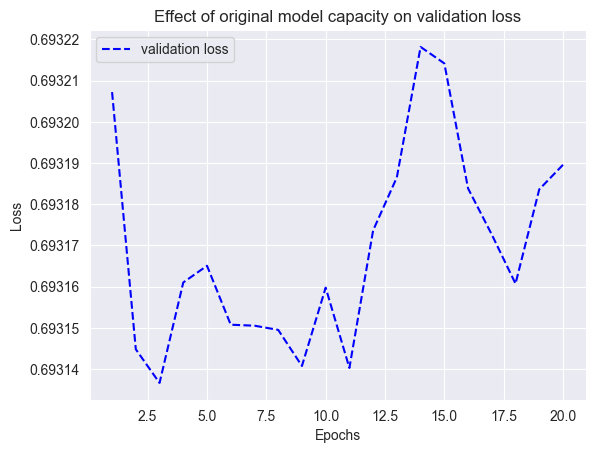

In [2]:
import  matplotlib.pyplot as plt
val_loss = history_original.history["val_loss"]
epochs = range(1,21)
plt.plot(epochs,val_loss,"b--",
         label="validation loss")
plt.title("Effect of original model capacity on validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

In [3]:
model = keras.Sequential([
    layers.Dense(4,activation="relu"),
    layers.Dense(4,activation="relu"),
    layers.Dense(1,activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history_small_model = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512,validation_split=0.2)

Epoch 1/20
40/40 [==============================] - 2s 22ms/step - loss: 0.6932 - accuracy: 0.4976 - val_loss: 0.6932 - val_accuracy: 0.4938
Epoch 2/20
40/40 [==============================] - 0s 10ms/step - loss: 0.6932 - accuracy: 0.5016 - val_loss: 0.6932 - val_accuracy: 0.4938
Epoch 3/20
40/40 [==============================] - 0s 12ms/step - loss: 0.6932 - accuracy: 0.5016 - val_loss: 0.6932 - val_accuracy: 0.4938
Epoch 4/20
40/40 [==============================] - 0s 10ms/step - loss: 0.6932 - accuracy: 0.5016 - val_loss: 0.6932 - val_accuracy: 0.4938
Epoch 5/20
40/40 [==============================] - 0s 8ms/step - loss: 0.6931 - accuracy: 0.5016 - val_loss: 0.6932 - val_accuracy: 0.4938
Epoch 6/20
40/40 [==============================] - 0s 11ms/step - loss: 0.6932 - accuracy: 0.5016 - val_loss: 0.6932 - val_accuracy: 0.4938
Epoch 7/20
40/40 [==============================] - 0s 10ms/step - loss: 0.6932 - accuracy: 0.5016 - val_loss: 0.6932 - val_accuracy: 0.4938
Epoch 8/20
40/

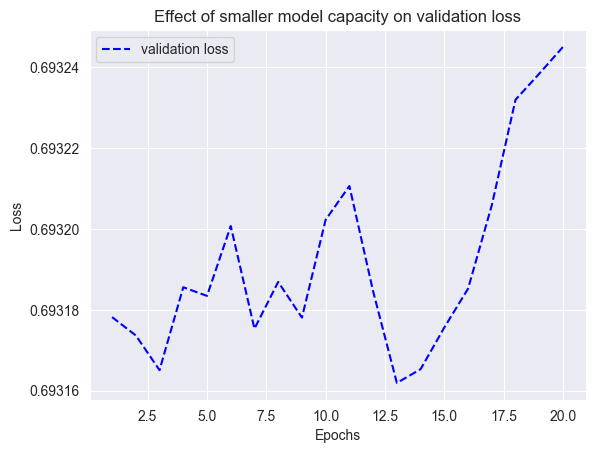

In [4]:
import matplotlib.pyplot as plt
val_loss = history_small_model.history["val_loss"]
epochs = range(1,21)
plt.plot(epochs,val_loss,"b--",
         label="validation loss")
plt.title("Effect of smaller model capacity on validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

In [5]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history_large_model = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.2
)

Epoch 1/20
40/40 [==============================] - 10s 225ms/step - loss: 0.6932 - accuracy: 0.4979 - val_loss: 0.6933 - val_accuracy: 0.4938
Epoch 2/20
40/40 [==============================] - 5s 134ms/step - loss: 0.6932 - accuracy: 0.4999 - val_loss: 0.6931 - val_accuracy: 0.4938
Epoch 3/20
40/40 [==============================] - 8s 200ms/step - loss: 0.6932 - accuracy: 0.4990 - val_loss: 0.6933 - val_accuracy: 0.4938
Epoch 4/20
40/40 [==============================] - 8s 195ms/step - loss: 0.6932 - accuracy: 0.5016 - val_loss: 0.6933 - val_accuracy: 0.4938
Epoch 5/20
40/40 [==============================] - 8s 204ms/step - loss: 0.6932 - accuracy: 0.5016 - val_loss: 0.6933 - val_accuracy: 0.4938
Epoch 6/20
40/40 [==============================] - 8s 206ms/step - loss: 0.6931 - accuracy: 0.5016 - val_loss: 0.6932 - val_accuracy: 0.4938
Epoch 7/20
40/40 [==============================] - 8s 209ms/step - loss: 0.6931 - accuracy: 0.5016 - val_loss: 0.6932 - val_accuracy: 0.4938
Epoch

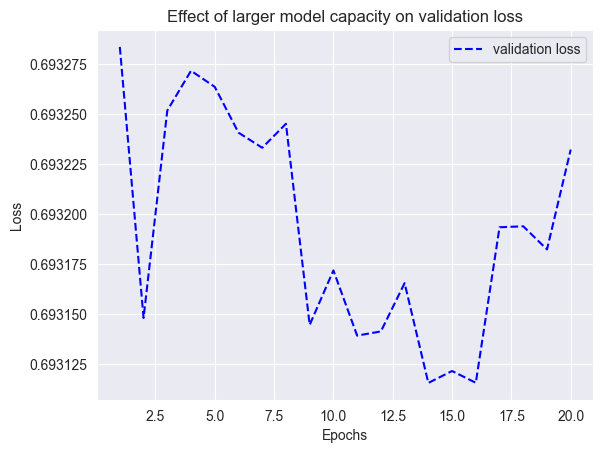

In [6]:
import matplotlib.pyplot as plt
val_loss = history_large_model.history["val_loss"]
epochs = range(1,21)
plt.plot(epochs,val_loss,"b--",
         label="validation loss")
plt.title("Effect of larger model capacity on validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

In [8]:
from keras import regularizers

model = keras.Sequential([
    layers.Dense(16,
                 kernel_regularizer=regularizers.l2(0.002),
                 activation="relu"),
    layers.Dense(16,
                 kernel_regularizer=regularizers.l2(0.002),
                 activation="relu"),
    layers.Dense(1,activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
history_l2_reg = model.fit(
    train_data,train_labels,
    epochs=20, batch_size=512, validation_split=0.4
)

Epoch 1/20
30/30 [==============================] - 2s 30ms/step - loss: 0.7682 - accuracy: 0.5011 - val_loss: 0.7493 - val_accuracy: 0.4967
Epoch 2/20
30/30 [==============================] - 0s 13ms/step - loss: 0.7383 - accuracy: 0.5022 - val_loss: 0.7283 - val_accuracy: 0.4967
Epoch 3/20
30/30 [==============================] - 0s 8ms/step - loss: 0.7222 - accuracy: 0.4998 - val_loss: 0.7165 - val_accuracy: 0.4967
Epoch 4/20
30/30 [==============================] - 0s 10ms/step - loss: 0.7128 - accuracy: 0.4966 - val_loss: 0.7093 - val_accuracy: 0.4967
Epoch 5/20
30/30 [==============================] - 0s 13ms/step - loss: 0.7069 - accuracy: 0.4995 - val_loss: 0.7046 - val_accuracy: 0.4967
Epoch 6/20
30/30 [==============================] - 0s 13ms/step - loss: 0.7029 - accuracy: 0.5022 - val_loss: 0.7013 - val_accuracy: 0.4967
Epoch 7/20
30/30 [==============================] - 0s 11ms/step - loss: 0.7001 - accuracy: 0.4977 - val_loss: 0.6989 - val_accuracy: 0.4967
Epoch 8/20
30/

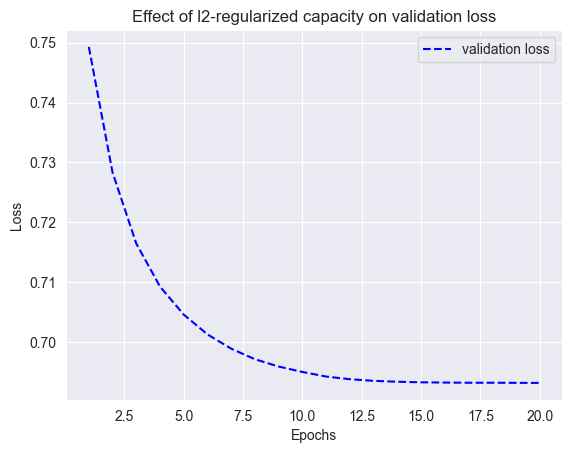

In [21]:
import matplotlib.pyplot as plt
val_loss = history_l2_reg.history["val_loss"]
epochs = range(1,21)
plt.plot(epochs,val_loss,"b--",
         label="validation loss")
plt.title("Effect of l2-regularized capacity on validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

In [22]:
from keras import regularizers
regularizers.l1(0.001)
regularizers.l1_l2(l1=0.001, l2=0.001)

In [27]:
model = keras.Sequential([
    layers.Dense(16,activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(16,activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1,activation="sigmoid")
])
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
history_dropout = model.fit(
    train_data,train_labels,
    epochs=20,batch_size=512,validation_split=0.4)

Epoch 1/20
30/30 [==============================] - 2s 35ms/step - loss: 0.6932 - accuracy: 0.5000 - val_loss: 0.6932 - val_accuracy: 0.4967
Epoch 2/20
30/30 [==============================] - 0s 12ms/step - loss: 0.6932 - accuracy: 0.5023 - val_loss: 0.6932 - val_accuracy: 0.4967
Epoch 3/20
30/30 [==============================] - 0s 14ms/step - loss: 0.6932 - accuracy: 0.5014 - val_loss: 0.6932 - val_accuracy: 0.4967
Epoch 4/20
30/30 [==============================] - 0s 13ms/step - loss: 0.6931 - accuracy: 0.5021 - val_loss: 0.6932 - val_accuracy: 0.4967
Epoch 5/20
30/30 [==============================] - 0s 11ms/step - loss: 0.6932 - accuracy: 0.5021 - val_loss: 0.6932 - val_accuracy: 0.4967
Epoch 6/20
30/30 [==============================] - 0s 12ms/step - loss: 0.6932 - accuracy: 0.5006 - val_loss: 0.6932 - val_accuracy: 0.4967
Epoch 7/20
30/30 [==============================] - 0s 14ms/step - loss: 0.6931 - accuracy: 0.5028 - val_loss: 0.6932 - val_accuracy: 0.4967
Epoch 8/20
30

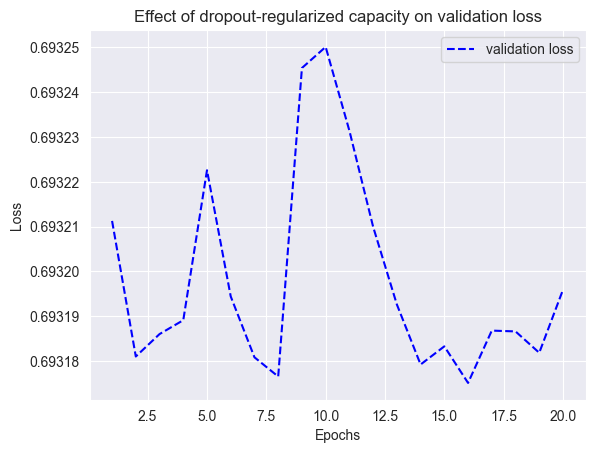

In [28]:
import matplotlib.pyplot as plt
val_loss = history_dropout.history["val_loss"]
epochs = range(1,21)
plt.plot(epochs,val_loss,"b--",
         label="validation loss")
plt.title("Effect of dropout-regularized capacity on validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()